# Energy Consumption Analysis — ESP32 CPU Frequency Comparison

Analyses Nordic PPK2 power-profiling data across **three CPU frequencies** (240, 160, 80 MHz) for the ESP32 Strawberry Monitoring System.

| Test | CPU Frequency | Sampling Rate | Data Location |
|------|--------------|---------------|---------------|
| Original (Test 1) | **240 MHz** | 10 kHz (0.1 ms) | Root folders |
| Test 3 | **160 MHz** | 100 Hz (10 ms) | `Test3/` subfolders |
| Test 2 | **80 MHz** | 100 Hz (10 ms) | `Test2/` subfolders |

Each test captures a **2-hour** recording per node. We analyse the **middle hour** (30–90 min) to avoid startup/shutdown transients.

### Sections
1. **CPU frequency comparison** — measured power profiles, bar charts, overlays, histograms
2. **Idle current investigation** — where does the deep-sleep current really go?
3. **System power breakdown** — pie charts of measured + datasheet components
4. **Proposed improvements** — quantified impact of hardware & firmware changes
5. **MQ3 alternative analysis** — why the MQ3 should be replaced
6. **Powerbank runtime projections** — current design vs improved design

## 1. Imports and Configuration

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import glob
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['font.size'] = 10

# ── Shared constants ──────────────────────────────────────────────────────────
SUPPLY_VOLTAGE    = 3.3
DOWNSAMPLE_FACTOR = 100
START_TIME_MS     = 30 * 60 * 1000
END_TIME_MS       = 90 * 60 * 1000

# ── Component current draws (from datasheets + measurements) ─────────────────
ESP32_DEEP_SLEEP_UA   = 10.0       # ESP32 chip deep sleep (datasheet)
DHT22_STANDBY_UA      = 60.0       # DHT22 standby (datasheet max)
SGP30_ACTIVE_UA       = 48_000.0   # SGP30 measurement mode, continuous (datasheet: 48 mA @ 1.8V via LDO)
DEVKIT_OVERHEAD_UA    = 12_000.0   # ESP32 DevKit board overhead: AMS1117 LDO (~5 mA) + USB-UART bridge + LED + pull-ups

# These sum to the measured ~60 mA idle baseline per slave node:
#   SGP30 (48 mA) + DevKit (12 mA) + DHT22 (0.06 mA) + ESP32 (0.01 mA) = ~60.07 mA

# Improved design constants
EFFICIENT_LDO_UA      = 2.0        # MCP1700 or similar: 1.6 uA quiescent
MOSFET_LEAKAGE_UA     = 1.0        # P-ch MOSFET leakage (< 1 uA)
BME680_SLEEP_UA       = 0.15       # BME680 sleep mode (replaces DHT22)
BME680_ACTIVE_UA      = 3_600.0    # BME680 during gas measurement (3.6 mA)

SENSOR_COUNT = 3  # nodes

# ── Powerbank specs ──────────────────────────────────────────────────────────
POWERBANK_MAH = [5000, 10000, 20000]
POWERBANK_EFF = 0.85

# ── Paths ─────────────────────────────────────────────────────────────────────
PPK2_BASE = r"c:\Users\cmahe\OneDrive\Desktop\SSE Masters\Thesis\PPK2 Data\CSV"

PATHS_240 = {
    'master_dir': os.path.join(PPK2_BASE, 'Master'),
    'node1': os.path.join(PPK2_BASE, 'Node1', 'Node1_energy.csv'),
    'node2': os.path.join(PPK2_BASE, 'Node2', 'Node2_energy.csv'),
}
PATHS_160 = {
    'master_dir': os.path.join(PPK2_BASE, 'Master', 'Test3'),
    'node1': os.path.join(PPK2_BASE, 'Node1', 'Test3', 'Node1_energy3.csv'),
    'node2': os.path.join(PPK2_BASE, 'Node2', 'Test3', 'Node2_energy3.csv'),
}
PATHS_80 = {
    'master_dir': os.path.join(PPK2_BASE, 'Master', 'Test2'),
    'node1': os.path.join(PPK2_BASE, 'Node1', 'Test2', 'Node1_energy2.csv'),
    'node2': os.path.join(PPK2_BASE, 'Node2', 'Test2', 'Node2_energy2.csv'),
}

PPK2_MQ3_FILE1 = os.path.join(PPK2_BASE, 'MQ3', 'MQ3_1.csv')
PPK2_MQ3_FILE2 = os.path.join(PPK2_BASE, 'MQ3', 'MQ3_2.csv')

MASTER_INDEX = {240: 1, 160: 0, 80: 0}
FREQS = [240, 160, 80]
FREQ_COLORS = {240: '#e74c3c', 160: '#3498db', 80: '#2ecc71'}
FREQ_LABELS = {240: '240 MHz', 160: '160 MHz', 80: '80 MHz'}

print('Configuration loaded.')

Configuration loaded.


## 2. Helper Functions

In [68]:
def load_ppk2_middle_hour(file_path, node_name, chunked=False):
    if not os.path.exists(file_path):
        print(f"  \u26a0 {node_name}: file not found"); return None
    try:
        if chunked:
            chunks = []
            for chunk in pd.read_csv(file_path, chunksize=1_000_000):
                mask = (chunk['Timestamp(ms)'] >= START_TIME_MS) & (chunk['Timestamp(ms)'] <= END_TIME_MS)
                part = chunk[mask]
                if len(part): chunks.append(part)
                if chunk['Timestamp(ms)'].max() > END_TIME_MS: break
            if not chunks: return None
            raw = pd.concat(chunks, ignore_index=True)
        else:
            raw = pd.read_csv(file_path)
            raw = raw[(raw['Timestamp(ms)'] >= START_TIME_MS) & (raw['Timestamp(ms)'] <= END_TIME_MS)].reset_index(drop=True)
        print(f"  \u2713 {node_name}: {len(raw):,} rows | avg {raw['Current(uA)'].mean()/1000:.3f} mA")
        return raw
    except Exception as exc:
        print(f"  \u26a0 {node_name}: {exc}"); return None

def process_ppk2(raw_df, downsample=True):
    if raw_df is None or len(raw_df) < 2: return None
    df = raw_df.iloc[::DOWNSAMPLE_FACTOR].copy() if downsample else raw_df.copy()
    df = df.reset_index(drop=True)
    df['time_sec']   = (df['Timestamp(ms)'] - df['Timestamp(ms)'].iloc[0]) / 1000
    df['current_ma'] = df['Current(uA)'] / 1000
    df['power_mw']   = df['current_ma'] * SUPPLY_VOLTAGE
    return df

def compute_energy_stats(df):
    if df is None: return None
    dur = df['time_sec'].max() - df['time_sec'].min()
    return {
        'duration_s': dur,
        'avg_current_ma': df['current_ma'].mean(),
        'peak_current_ma': df['current_ma'].max(),
        'idle_current_ma': df['current_ma'].quantile(0.05),
        'avg_power_mw': df['power_mw'].mean(),
        'energy_j': (df['power_mw'].mean() / 1000) * dur,
    }

print('Helper functions defined.')

Helper functions defined.


## 3. Load All Data (240 MHz, 160 MHz, 80 MHz)

In [69]:
%%time
raw_data = {}
processed = {}
ALL_PATHS = {240: PATHS_240, 160: PATHS_160, 80: PATHS_80}

for freq in FREQS:
    paths = ALL_PATHS[freq]
    chunked = (freq == 240)
    print(f"\n{'='*75}")
    print(f"LOADING {freq} MHz DATA" + (" (10 kHz, chunked)" if chunked else " (100 Hz)"))
    print(f"{'='*75}")
    mf = sorted(glob.glob(os.path.join(paths['master_dir'], '*.csv')))
    idx = MASTER_INDEX.get(freq, 0)
    mr = load_ppk2_middle_hour(mf[idx], f"Master ({freq} MHz)", chunked=chunked) if idx < len(mf) else None
    n1 = load_ppk2_middle_hour(paths['node1'], f"Node 1 ({freq} MHz)", chunked=chunked)
    n2 = load_ppk2_middle_hour(paths['node2'], f"Node 2 ({freq} MHz)", chunked=chunked)
    raw_data[freq] = {'master': mr, 'node1': n1, 'node2': n2}
    processed[freq] = {
        'master': process_ppk2(mr, downsample=chunked),
        'node1':  process_ppk2(n1, downsample=chunked),
        'node2':  process_ppk2(n2, downsample=chunked),
    }

# MQ3
print(f"\n{'='*75}")
print("LOADING MQ3 DATA (externally powered)")
print(f"{'='*75}")
mq3_r1 = pd.read_csv(PPK2_MQ3_FILE1) if os.path.exists(PPK2_MQ3_FILE1) else None
mq3_r2 = pd.read_csv(PPK2_MQ3_FILE2) if os.path.exists(PPK2_MQ3_FILE2) else None
if mq3_r1 is not None and mq3_r2 is not None:
    mq3_raw = mq3_r1.copy()
    mq3_raw['Current(uA)'] = (mq3_r1['Current(uA)'].values + mq3_r2['Current(uA)'].values) / 2
    print(f"  Averaged 2 runs: {mq3_raw['Current(uA)'].mean()/1000:.1f} mA")
else:
    mq3_raw = mq3_r1 or mq3_r2
mq3_df = process_ppk2(mq3_raw, downsample=False) if mq3_raw is not None else None

# Summary
NODES = ['master', 'node1', 'node2']
NODE_LABELS = {'master': 'Master Node', 'node1': 'Node 1 (Slave)', 'node2': 'Node 2 (Slave)'}
TX_TIMES = [t * 60 for t in [0, 15, 30, 45, 60]]

print(f"\n{'='*75}")
print("LOADING SUMMARY")
print(f"{'='*75}")
for freq in FREQS:
    for node in NODES:
        df = processed[freq][node]
        if df is not None:
            print(f"  {freq:>3} MHz {node:<8} {len(df):>10,} rows | avg {df['current_ma'].mean():.3f} mA | idle(5th) {df['current_ma'].quantile(0.05):.3f} mA")
if mq3_df is not None:
    print(f"  MQ3 (ext)       {len(mq3_df):>10,} rows | avg {mq3_df['current_ma'].mean():.1f} mA")


LOADING 240 MHz DATA (10 kHz, chunked)
  ✓ Master (240 MHz): 36,000,001 rows | avg 88.795 mA
  ✓ Node 1 (240 MHz): 36,000,001 rows | avg 64.752 mA
  ✓ Node 2 (240 MHz): 36,000,001 rows | avg 66.144 mA

LOADING 160 MHz DATA (100 Hz)
  ✓ Master (160 MHz): 360,001 rows | avg 90.938 mA
  ✓ Node 1 (160 MHz): 360,001 rows | avg 65.577 mA
  ✓ Node 2 (160 MHz): 360,001 rows | avg 66.811 mA

LOADING 80 MHz DATA (100 Hz)
  ✓ Master (80 MHz): 360,001 rows | avg 94.083 mA
  ✓ Node 1 (80 MHz): 360,001 rows | avg 65.108 mA
  ✓ Node 2 (80 MHz): 360,001 rows | avg 67.269 mA

LOADING MQ3 DATA (externally powered)
  Averaged 2 runs: 312.9 mA

LOADING SUMMARY
  240 MHz master      360,001 rows | avg 88.789 mA | idle(5th) 81.742 mA
  240 MHz node1       360,001 rows | avg 64.751 mA | idle(5th) 61.458 mA
  240 MHz node2       360,001 rows | avg 66.127 mA | idle(5th) 63.199 mA
  160 MHz master      360,001 rows | avg 90.938 mA | idle(5th) 84.608 mA
  160 MHz node1       360,001 rows | avg 65.577 mA | idle(

## 4. Power Profiles per CPU Frequency

One row per node, one column per frequency (240 -> 160 -> 80 MHz).

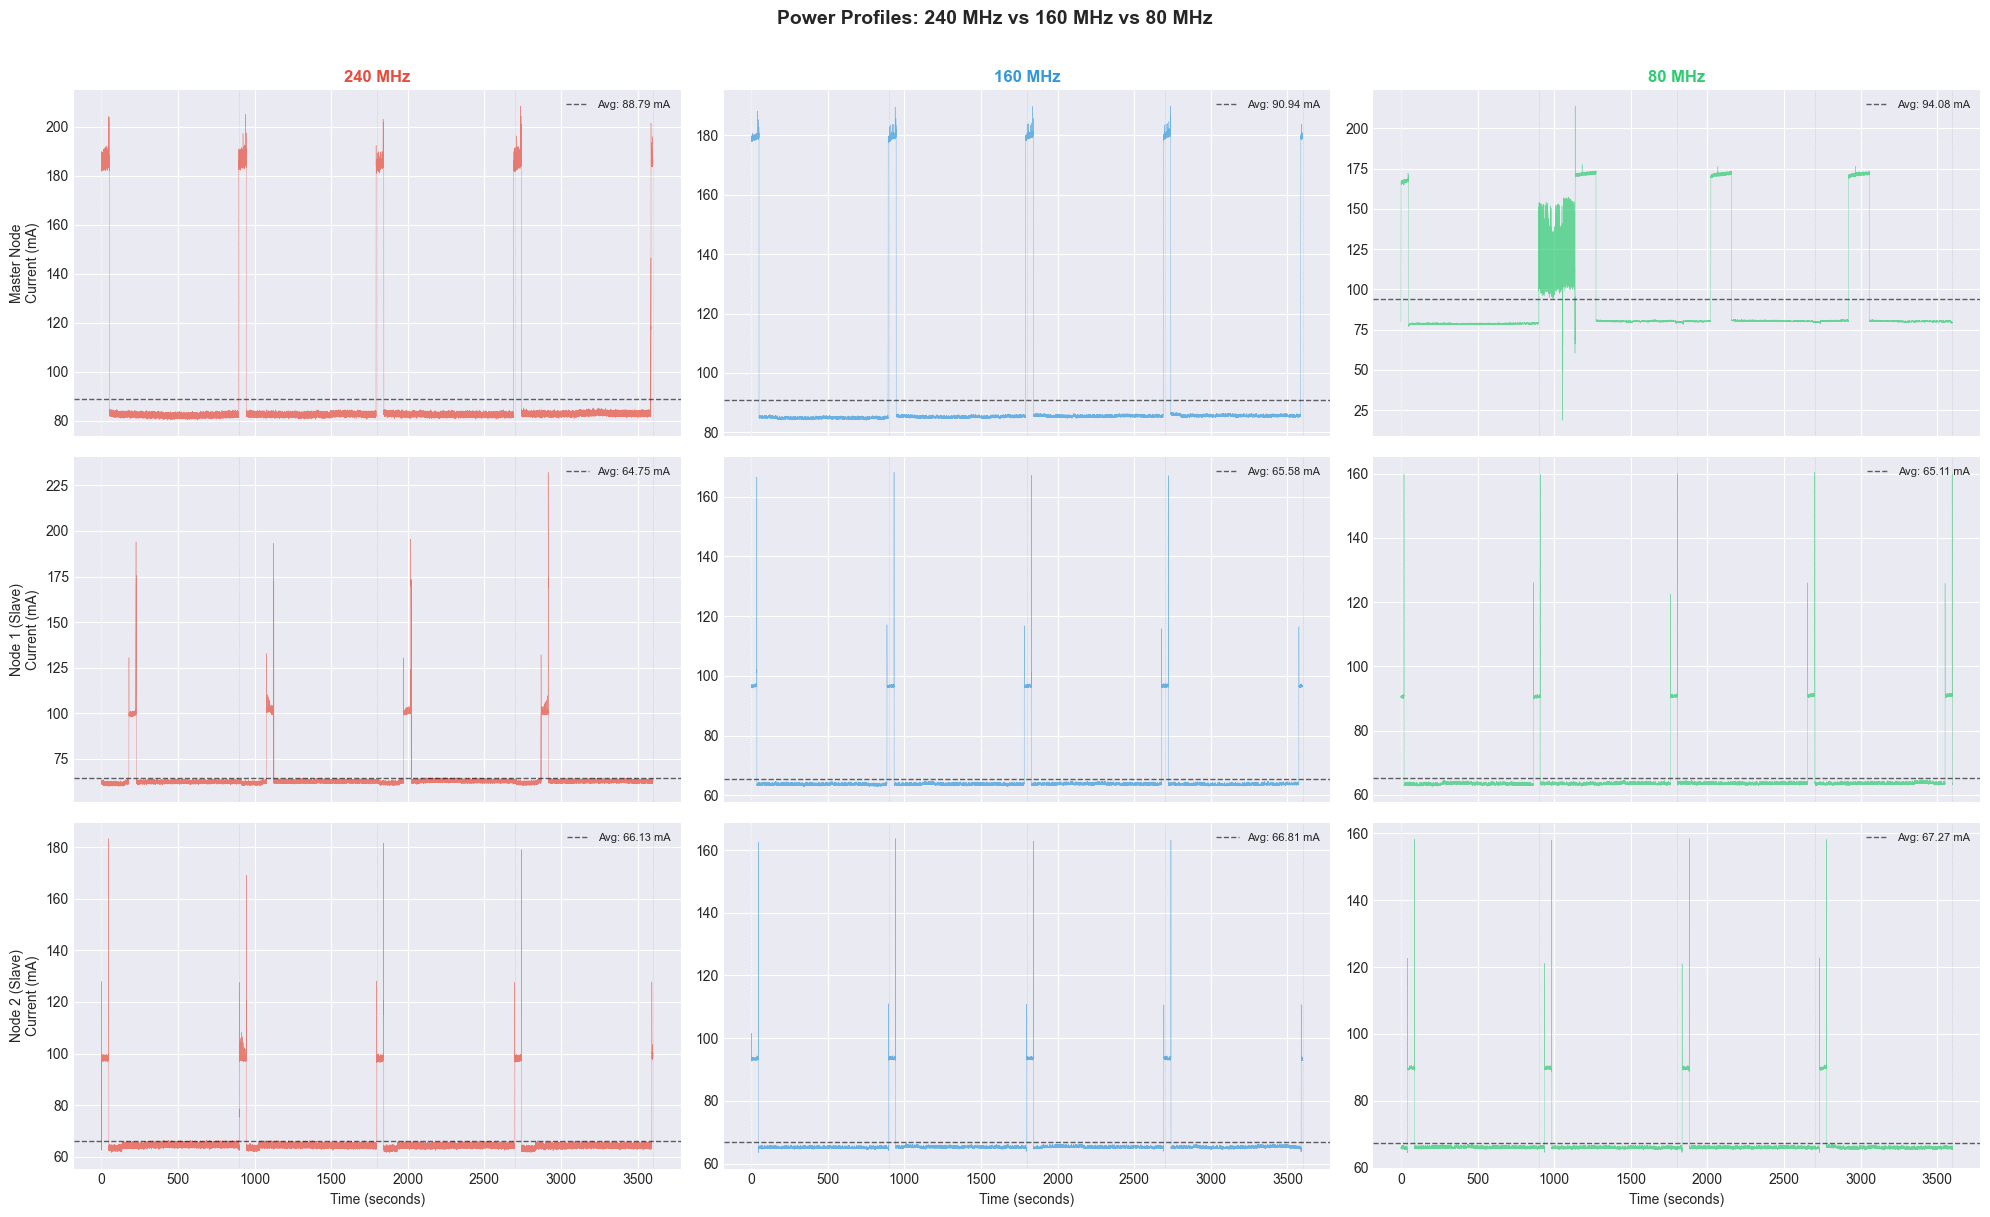

In [70]:
fig, axes = plt.subplots(len(NODES), len(FREQS), figsize=(20, 12), sharex=True)
for row, node in enumerate(NODES):
    for col, freq in enumerate(FREQS):
        ax = axes[row, col]; df = processed[freq][node]; color = FREQ_COLORS[freq]
        if df is not None:
            ax.plot(df['time_sec'], df['current_ma'], linewidth=0.3, alpha=0.7, color=color)
            avg = df['current_ma'].mean()
            ax.axhline(avg, color='black', linestyle='--', linewidth=1, alpha=0.6, label=f'Avg: {avg:.2f} mA')
            for tx in TX_TIMES:
                ax.axvline(tx, color='gray', linestyle=':', linewidth=0.5, alpha=0.4)
            ax.legend(fontsize=8, loc='upper right')
        if row == 0: ax.set_title(FREQ_LABELS[freq], fontsize=12, fontweight='bold', color=color)
        if col == 0: ax.set_ylabel(f'{NODE_LABELS[node]}\nCurrent (mA)', fontsize=10)
        if row == len(NODES) - 1: ax.set_xlabel('Time (seconds)', fontsize=10)
fig.suptitle('Power Profiles: 240 MHz vs 160 MHz vs 80 MHz', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

## 5. CPU Frequency Comparison — Key Metrics

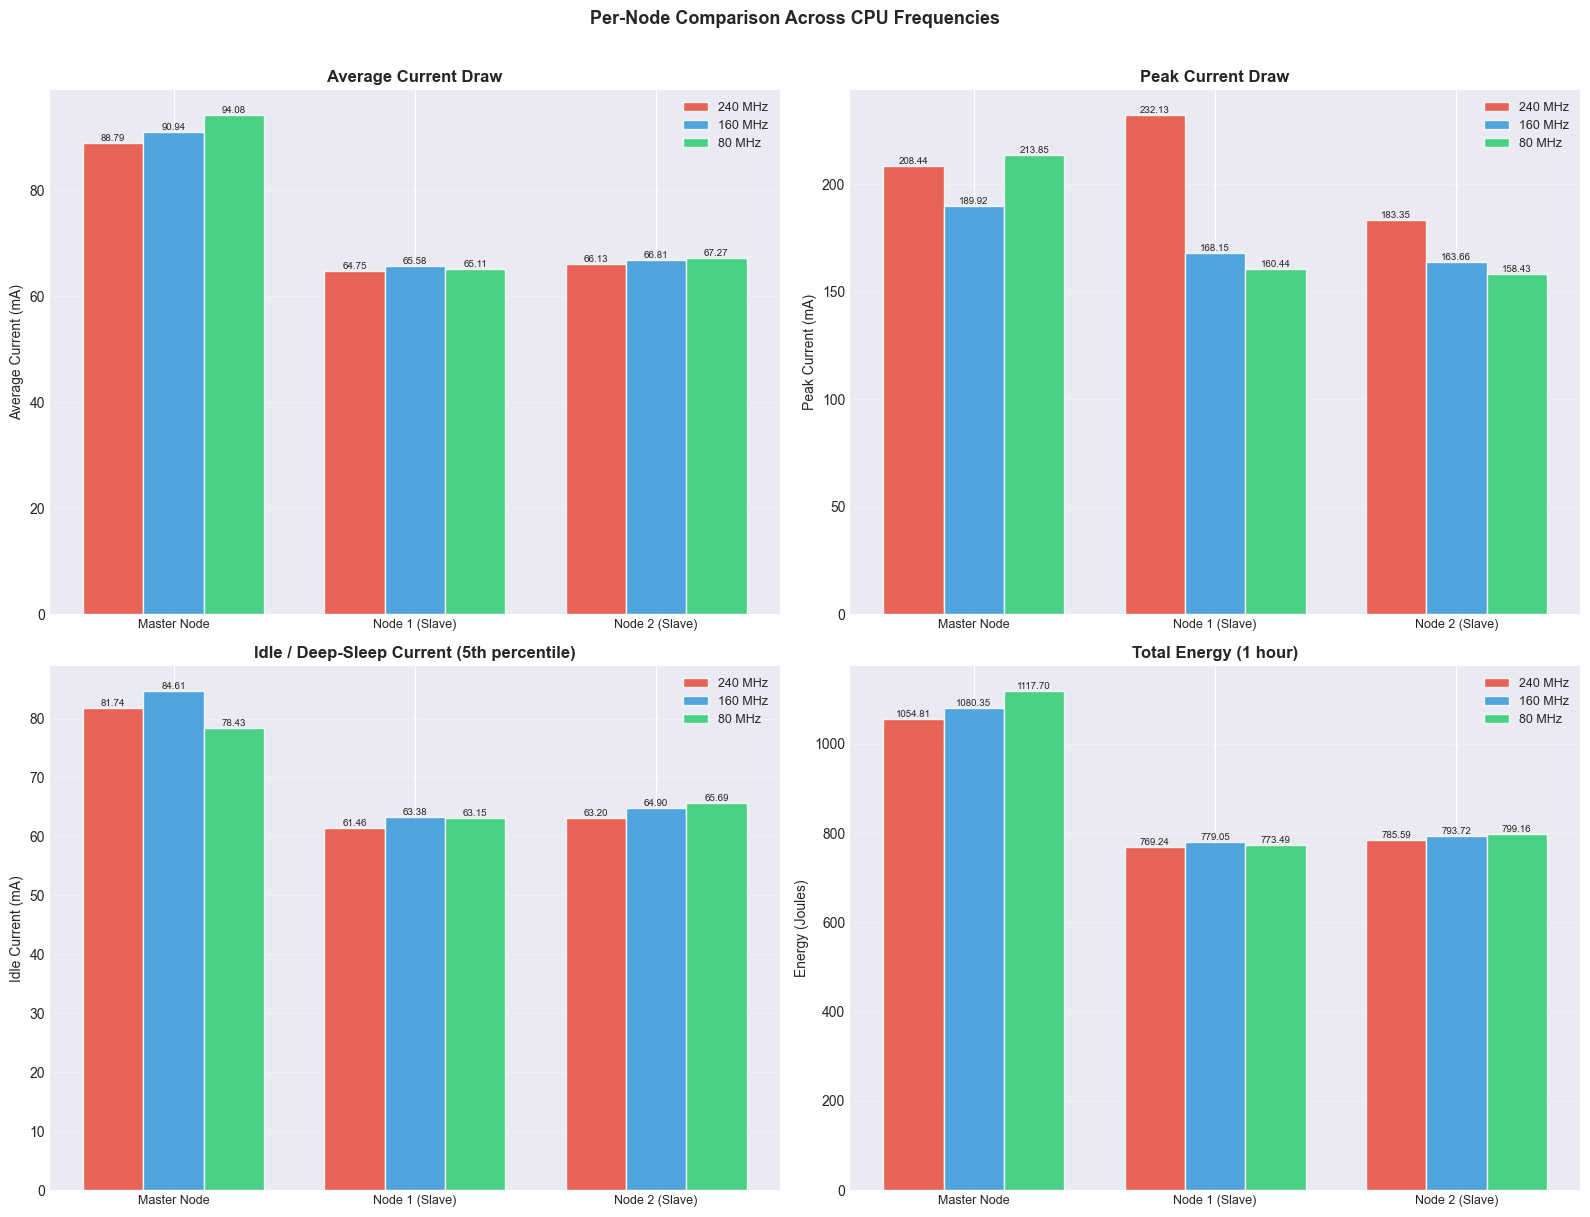

In [71]:
all_stats = []
for freq in FREQS:
    for node in NODES:
        df = processed[freq][node]; s = compute_energy_stats(df)
        if s: s['freq'] = freq; s['node'] = NODE_LABELS[node]; all_stats.append(s)
stats_df = pd.DataFrame(all_stats)

sys_stats = []
for freq in FREQS:
    fd = stats_df[stats_df['freq'] == freq]
    if len(fd) == 3:
        sys_stats.append({'freq': freq,
            'total_avg_current_ma': fd['avg_current_ma'].sum(),
            'total_avg_power_mw': fd['avg_power_mw'].sum(),
            'total_energy_j': fd['energy_j'].sum(),
            'avg_idle_ma': fd['idle_current_ma'].mean()})
sys_df = pd.DataFrame(sys_stats)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
metrics = [
    ('avg_current_ma', 'Average Current (mA)', 'Average Current Draw'),
    ('peak_current_ma', 'Peak Current (mA)', 'Peak Current Draw'),
    ('idle_current_ma', 'Idle Current (mA)', 'Idle / Deep-Sleep Current (5th percentile)'),
    ('energy_j', 'Energy (Joules)', 'Total Energy (1 hour)'),
]
x = np.arange(len(NODES)); width = 0.25
for ax, (metric, ylabel, title) in zip(axes.flat, metrics):
    for i, freq in enumerate(FREQS):
        vals = [stats_df[(stats_df['freq']==freq)&(stats_df['node']==NODE_LABELS[n])][metric].values[0]
                if len(stats_df[(stats_df['freq']==freq)&(stats_df['node']==NODE_LABELS[n])]) else 0 for n in NODES]
        bars = ax.bar(x + i*width, vals, width, label=FREQ_LABELS[freq], color=FREQ_COLORS[freq], alpha=0.85, edgecolor='white')
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(), f'{v:.2f}', ha='center', va='bottom', fontsize=7)
    ax.set_xticks(x+width); ax.set_xticklabels([NODE_LABELS[n] for n in NODES], fontsize=9)
    ax.set_ylabel(ylabel); ax.set_title(title, fontweight='bold'); ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
plt.suptitle('Per-Node Comparison Across CPU Frequencies', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

## 6. System-Level Energy Comparison

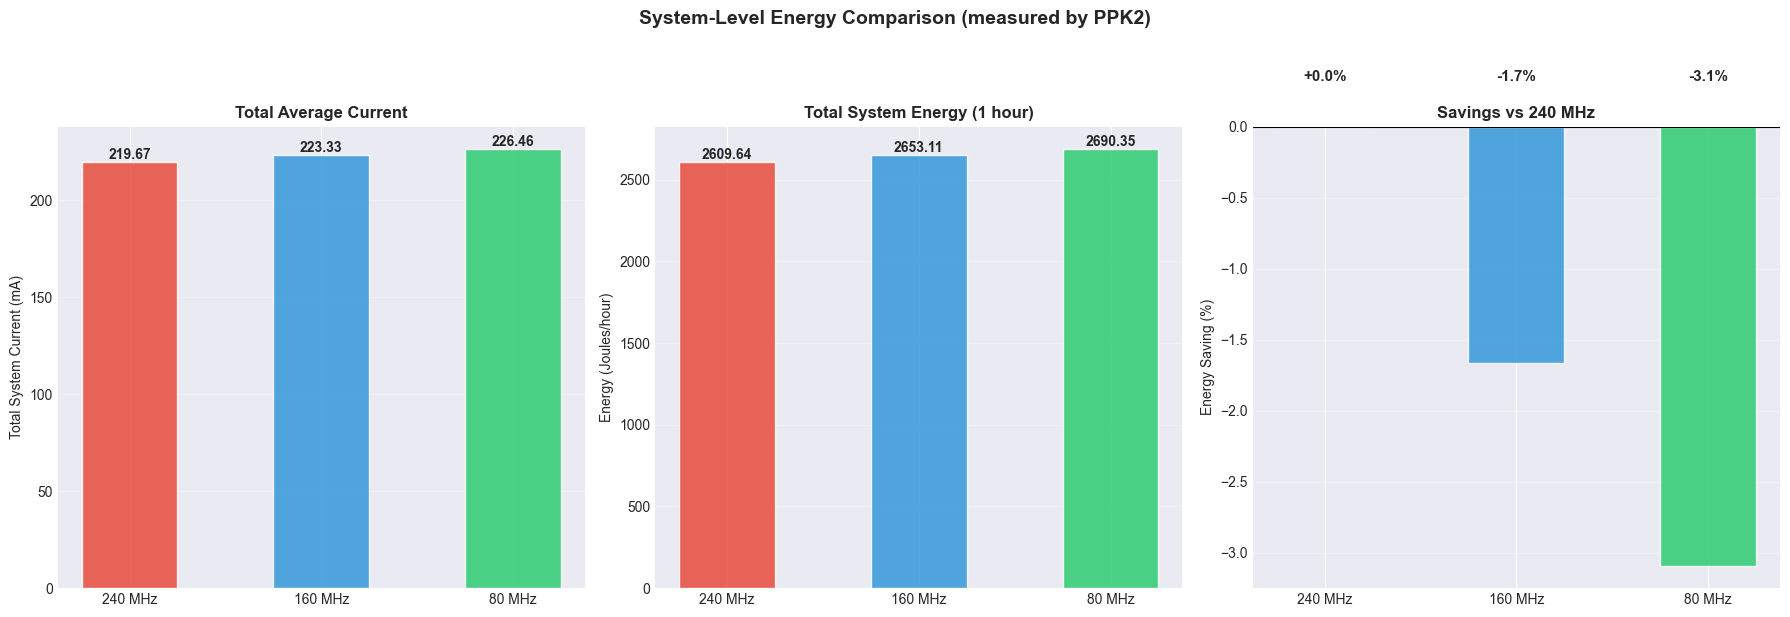


SYSTEM ENERGY SUMMARY (3 nodes, 1 hour)
  240 MHz    219.67 mA | 2609.64 J | +0.0%
  160 MHz    223.33 mA | 2653.11 J | -1.7%
  80 MHz     226.46 mA | 2690.35 J | -3.1%


In [72]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
baseline = sys_df[sys_df['freq']==240]['total_energy_j'].values[0]

for ax, col_name, ylabel, title in [
    (axes[0], 'total_avg_current_ma', 'Total System Current (mA)', 'Total Average Current'),
    (axes[1], 'total_energy_j', 'Energy (Joules/hour)', 'Total System Energy (1 hour)'),
]:
    bars = ax.bar([FREQ_LABELS[f] for f in sys_df['freq']], sys_df[col_name],
                  color=[FREQ_COLORS[f] for f in sys_df['freq']], alpha=0.85, edgecolor='white', width=0.5)
    for bar, v in zip(bars, sys_df[col_name]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(), f'{v:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_ylabel(ylabel); ax.set_title(title, fontweight='bold'); ax.grid(axis='y', alpha=0.3)

ax = axes[2]
savings = [(1 - r['total_energy_j']/baseline)*100 for _, r in sys_df.iterrows()]
bars = ax.bar([FREQ_LABELS[f] for f in sys_df['freq']], savings,
              color=[FREQ_COLORS[f] for f in sys_df['freq']], alpha=0.85, edgecolor='white', width=0.5)
for bar, v in zip(bars, savings):
    ax.text(bar.get_x()+bar.get_width()/2, max(bar.get_height(),0)+0.3, f'{v:+.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Energy Saving (%)'); ax.set_title('Savings vs 240 MHz', fontweight='bold')
ax.axhline(0, color='black', linewidth=0.8); ax.grid(axis='y', alpha=0.3)
plt.suptitle('System-Level Energy Comparison (measured by PPK2)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

print(f"\n{'='*75}")
print("SYSTEM ENERGY SUMMARY (3 nodes, 1 hour)")
print(f"{'='*75}")
for _, r in sys_df.iterrows():
    s = (1 - r['total_energy_j']/baseline)*100
    print(f"  {FREQ_LABELS[r['freq']]:<10} {r['total_avg_current_ma']:.2f} mA | {r['total_energy_j']:.2f} J | {s:+.1f}%")

## 7. Overlaid Current Traces — Per Node

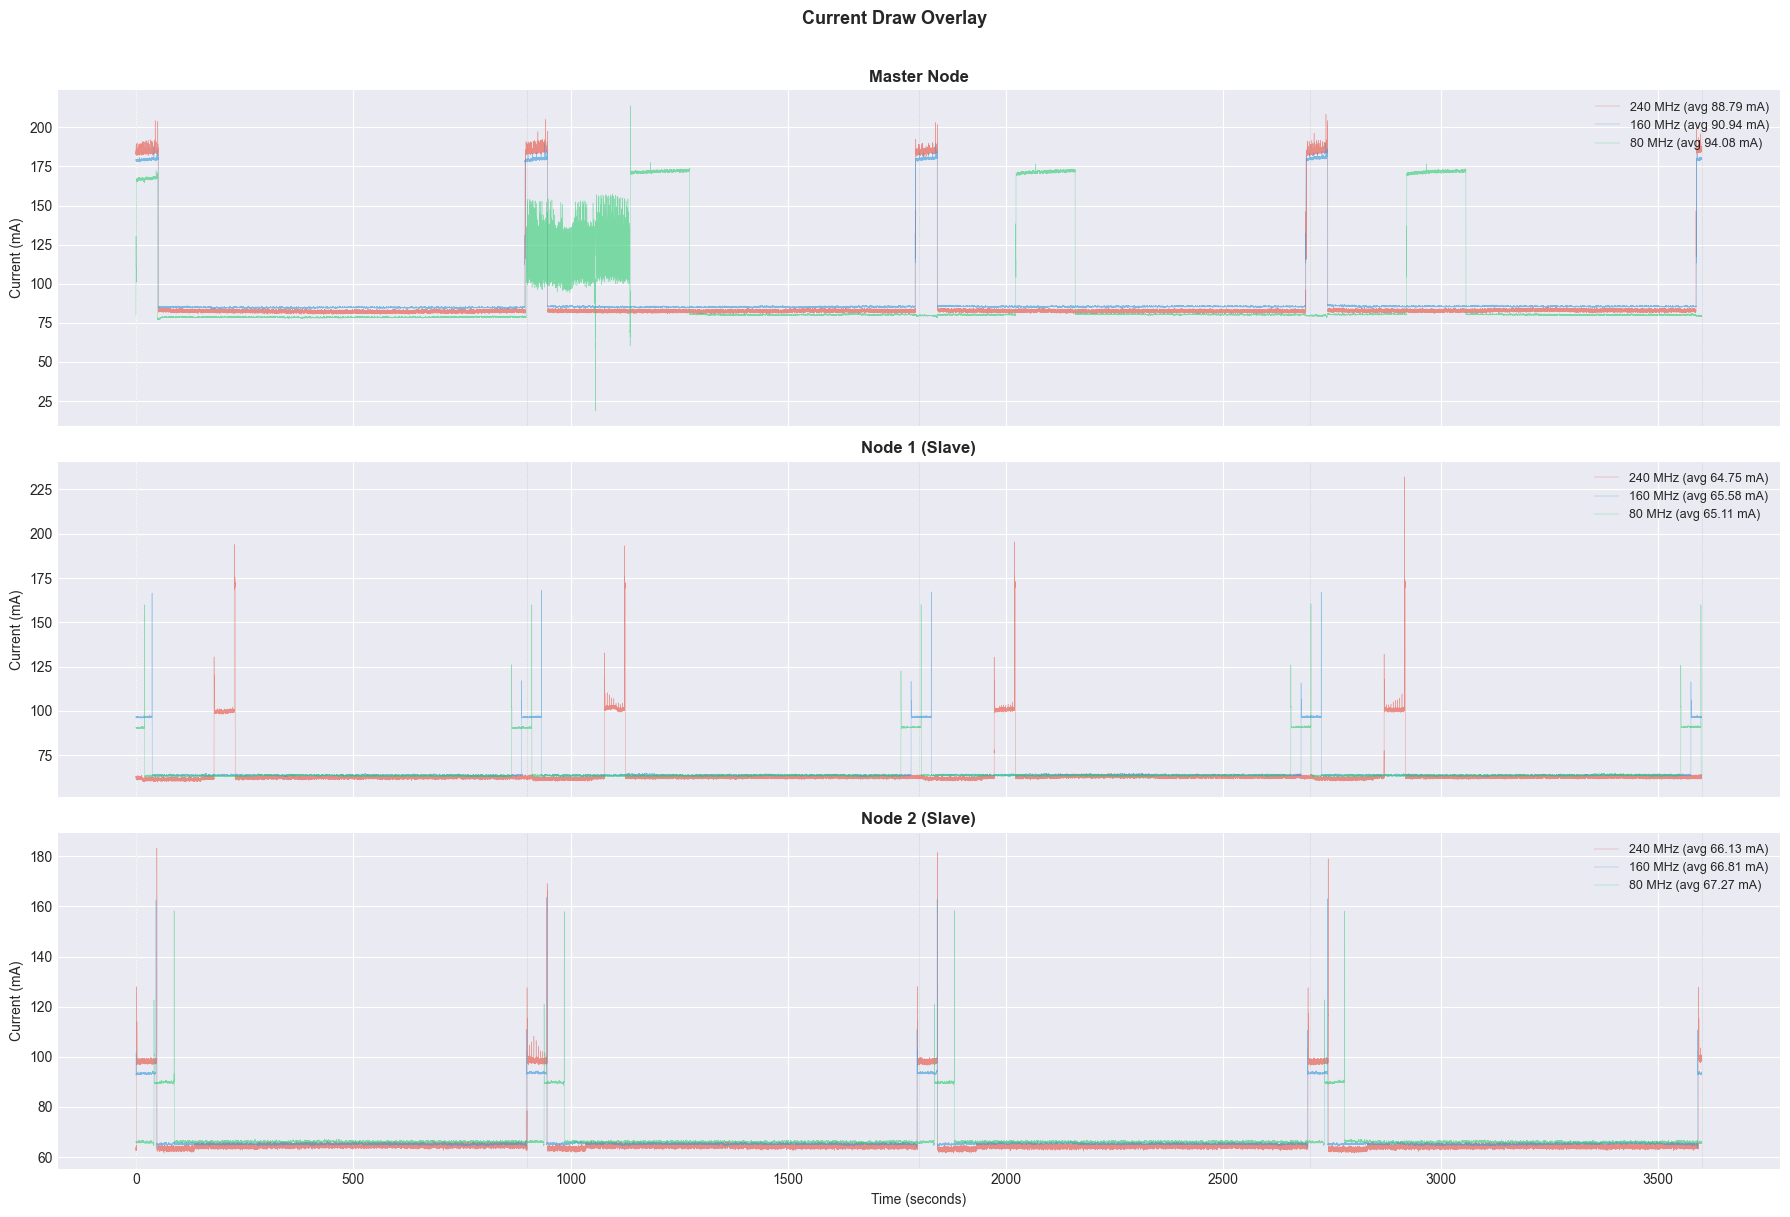

In [73]:
fig, axes = plt.subplots(len(NODES), 1, figsize=(18, 4*len(NODES)), sharex=True)
for ax, node in zip(axes, NODES):
    for freq in FREQS:
        df = processed[freq][node]
        if df is not None:
            ax.plot(df['time_sec'], df['current_ma'], linewidth=0.3, alpha=0.6,
                    color=FREQ_COLORS[freq], label=f"{FREQ_LABELS[freq]} (avg {df['current_ma'].mean():.2f} mA)")
    for tx in TX_TIMES: ax.axvline(tx, color='gray', linestyle=':', linewidth=0.5, alpha=0.4)
    ax.set_ylabel('Current (mA)'); ax.set_title(NODE_LABELS[node], fontweight='bold')
    ax.legend(fontsize=9, loc='upper right')
axes[-1].set_xlabel('Time (seconds)')
fig.suptitle('Current Draw Overlay', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

## 8. Current Distribution Analysis

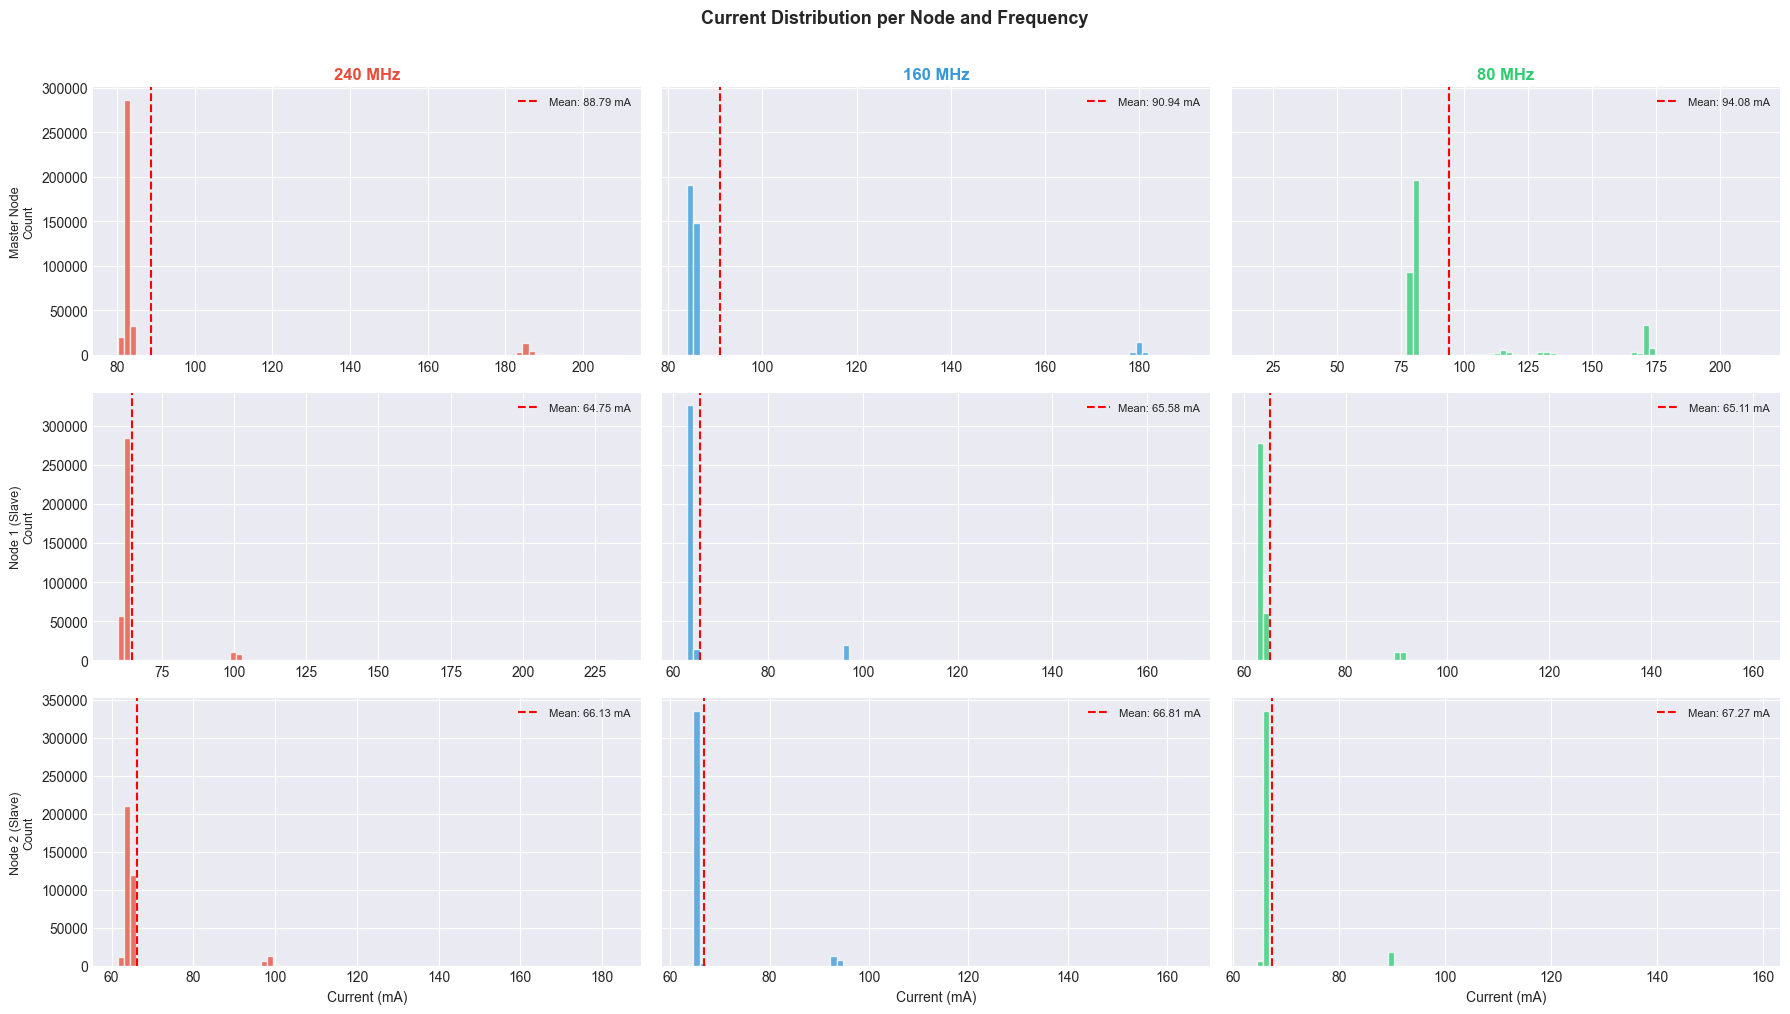

In [74]:
fig, axes = plt.subplots(len(NODES), len(FREQS), figsize=(18, 10), sharey='row')
for row, node in enumerate(NODES):
    for col, freq in enumerate(FREQS):
        ax = axes[row, col]; df = processed[freq][node]
        if df is not None:
            ax.hist(df['current_ma'], bins=80, color=FREQ_COLORS[freq], alpha=0.75, edgecolor='white')
            m = df['current_ma'].mean()
            ax.axvline(m, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {m:.2f} mA')
            ax.legend(fontsize=8)
        if row==0: ax.set_title(FREQ_LABELS[freq], fontweight='bold', color=FREQ_COLORS[freq])
        if col==0: ax.set_ylabel(f'{NODE_LABELS[node]}\nCount', fontsize=9)
        if row==len(NODES)-1: ax.set_xlabel('Current (mA)')
fig.suptitle('Current Distribution per Node and Frequency', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

## 9. Idle Current Investigation — Where Does the Power Go?

The PPK2 data reveals a critical finding: **slave nodes never drop below ~60 mA**, even during deep sleep. The ESP32 chip itself should draw only ~10 µA in deep sleep. So where does the other ~60 mA come from?

### Measured vs Expected Idle Current

| Component | Expected Current | Source |
|-----------|-----------------|--------|
| ESP32 chip (deep sleep) | 10 µA (0.01 mA) | ESP32 datasheet |
| DHT22 (standby) | 60 µA (0.06 mA) | AM2302 datasheet |
| **SGP30 (measurement mode)** | **48 mA** | Sensirion SGP30 datasheet — runs continuously unless `sgp30_sleep` I2C command sent |
| **ESP32 DevKit overhead** | **~12 mA** | AMS1117 LDO (~5 mA) + CP2102 USB-UART + power LED + pull-ups |
| **Total expected** | **~60.07 mA** | **Matches measured ~60–65 mA** |

The SGP30 is the dominant consumer at **48 mA** (80% of idle power), and the DevKit board overhead accounts for another **~12 mA** (20%). The actual ESP32 deep sleep and DHT22 are negligible.

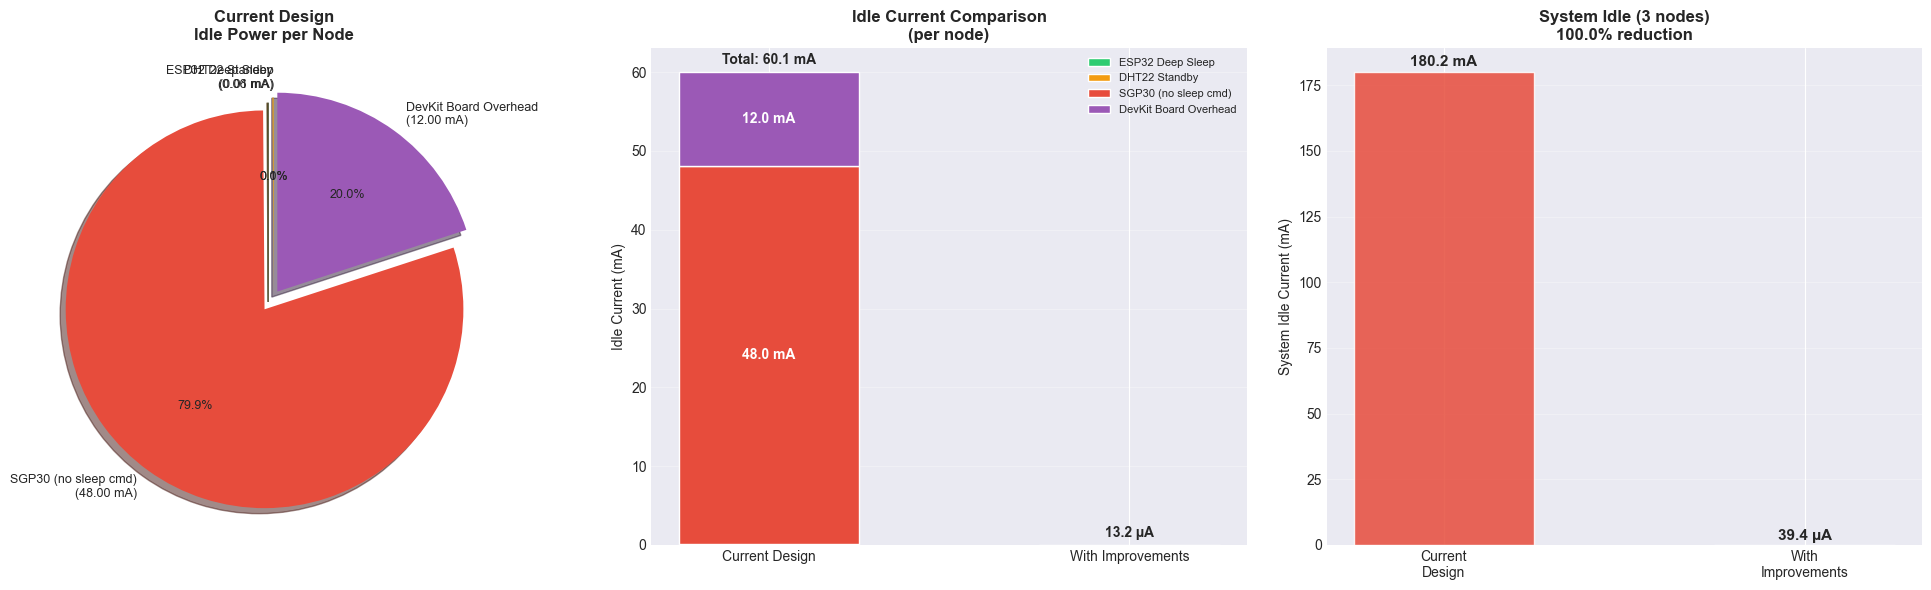


Per-node idle: 60.070 mA -> 13.15 uA  (99.98% reduction)
System idle:   180.210 mA -> 39.45 uA  (99.98% reduction)

Factor improvement: 4568x per node


In [75]:
# ── Stacked bar + pie: idle current breakdown ─────────────────────────────────
components = {
    'ESP32 Deep Sleep':   ESP32_DEEP_SLEEP_UA / 1000,
    'DHT22 Standby':      DHT22_STANDBY_UA / 1000,
    'SGP30 (no sleep cmd)': SGP30_ACTIVE_UA / 1000,
    'DevKit Board Overhead': DEVKIT_OVERHEAD_UA / 1000,
}
comp_colors = ['#2ecc71', '#f39c12', '#e74c3c', '#9b59b6']

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

# ── Pie chart: current design idle breakdown ──────────────────────────────────
vals = list(components.values())
labs = list(components.keys())
ax1.pie(vals, labels=[f'{l}\n({v:.2f} mA)' for l, v in zip(labs, vals)],
        colors=comp_colors, autopct='%1.1f%%', startangle=90,
        textprops={'fontsize': 9}, explode=[0, 0, 0.08, 0.03], shadow=True)
ax1.set_title('Current Design\nIdle Power per Node', fontsize=12, fontweight='bold')

# ── Stacked bar: current vs improved ─────────────────────────────────────────
# Current design
bottom = 0
for label, val, col in zip(labs, vals, comp_colors):
    ax2.bar(0, val, bottom=bottom, color=col, width=0.5, edgecolor='white', label=label)
    if val > 1: ax2.text(0, bottom + val/2, f'{val:.1f} mA', ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    bottom += val
ax2.text(0, bottom + 1, f'Total: {sum(vals):.1f} mA', ha='center', fontsize=10, fontweight='bold')

# Improved design (MOSFET gates + custom PCB)
improved_idle = (ESP32_DEEP_SLEEP_UA + EFFICIENT_LDO_UA + MOSFET_LEAKAGE_UA + BME680_SLEEP_UA) / 1000
ax2.bar(1, improved_idle, color='#2ecc71', width=0.5, edgecolor='white')
ax2.text(1, improved_idle + 1, f'{improved_idle*1000:.1f} \u00b5A', ha='center', fontsize=10, fontweight='bold')

ax2.set_xticks([0, 1]); ax2.set_xticklabels(['Current Design', 'With Improvements'], fontsize=10)
ax2.set_ylabel('Idle Current (mA)'); ax2.set_title('Idle Current Comparison\n(per node)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=8, loc='upper right'); ax2.grid(axis='y', alpha=0.3)

# ── System level (x3 nodes) ──────────────────────────────────────────────────
system_current = sum(vals) * 3
system_improved = improved_idle * 3
reduction = (1 - system_improved / system_current) * 100

bars = ax3.bar(['Current\nDesign', 'With\nImprovements'], [system_current, system_improved],
               color=['#e74c3c', '#2ecc71'], alpha=0.85, edgecolor='white', width=0.5)
ax3.text(0, system_current + 2, f'{system_current:.1f} mA', ha='center', fontsize=11, fontweight='bold')
ax3.text(1, system_improved + 2, f'{system_improved*1000:.1f} \u00b5A', ha='center', fontsize=11, fontweight='bold')
ax3.set_ylabel('System Idle Current (mA)'); ax3.set_title(f'System Idle (3 nodes)\n{reduction:.1f}% reduction', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()

print(f"\nPer-node idle: {sum(vals):.3f} mA -> {improved_idle*1000:.2f} uA  ({(1-improved_idle/sum(vals))*100:.2f}% reduction)")
print(f"System idle:   {system_current:.3f} mA -> {system_improved*1000:.2f} uA  ({reduction:.2f}% reduction)")
print(f"\nFactor improvement: {sum(vals)/improved_idle:.0f}x per node")

## 10. System Power Breakdown — Pie Charts

Shows total system power budget including all components. The ESP32 measurements from the PPK2 include the SGP30, DHT22, and DevKit overhead (they share the same power rail). The MQ3 is externally powered.

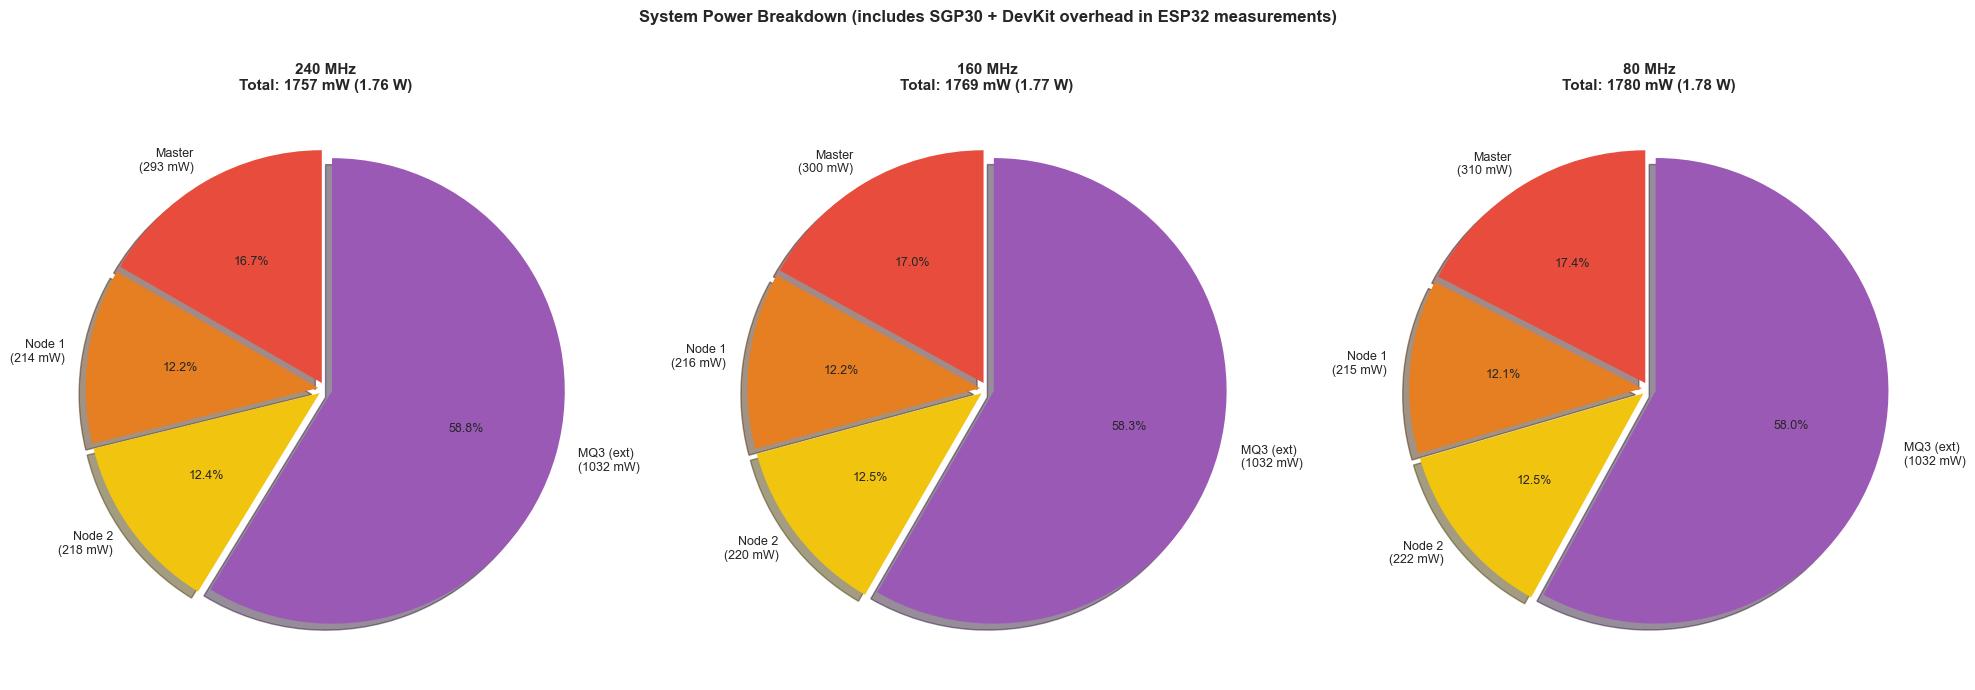

In [76]:
fig, axes = plt.subplots(1, len(FREQS), figsize=(20, 7))

for ax, freq in zip(axes, FREQS):
    master_mw = processed[freq]['master']['power_mw'].mean() if processed[freq]['master'] is not None else 0
    node1_mw  = processed[freq]['node1']['power_mw'].mean() if processed[freq]['node1'] is not None else 0
    node2_mw  = processed[freq]['node2']['power_mw'].mean() if processed[freq]['node2'] is not None else 0
    mq3_mw = mq3_df['power_mw'].mean() if mq3_df is not None else 0

    slices = [master_mw, node1_mw, node2_mw, mq3_mw]
    labels = [f'Master\n({master_mw:.0f} mW)', f'Node 1\n({node1_mw:.0f} mW)',
              f'Node 2\n({node2_mw:.0f} mW)', f'MQ3 (ext)\n({mq3_mw:.0f} mW)']
    colors_pie = ['#e74c3c', '#e67e22', '#f1c40f', '#9b59b6']

    non_zero = [(s,l,c) for s,l,c in zip(slices, labels, colors_pie) if s > 0]
    if non_zero:
        v, la, co = zip(*non_zero)
        ax.pie(v, labels=la, colors=co, autopct='%1.1f%%', startangle=90,
               textprops={'fontsize': 9}, explode=[0.03]*len(v), shadow=True)
    total = sum(slices)
    ax.set_title(f'{FREQ_LABELS[freq]}\nTotal: {total:.0f} mW ({total/1000:.2f} W)', fontsize=11, fontweight='bold')

fig.suptitle('System Power Breakdown (includes SGP30 + DevKit overhead in ESP32 measurements)', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

## 11. MQ3 Sensor Analysis & Alternative

### The Problem
The MQ3 alcohol/gas sensor uses a resistive **heater element** that draws **~310 mA** (over 1 W at 3.3 V). This is why it was powered externally — it would flatten any battery in hours.

### Recommended Alternative: **Bosch BME680 / BME688**

| Feature | MQ3 | BME680 |
|---------|-----|--------|
| Measures | Alcohol/ethanol | VOC, temperature, humidity, pressure |
| Active current | **310 mA** | **3.6 mA** (86x less) |
| Sleep current | N/A (always on) | **0.15 µA** |
| Interface | Analog voltage | I2C (digital) |
| Warm-up time | 24+ hours for stable readings | ~30 seconds |
| Cost | ~€3 | ~€10 (breakout) |

The BME680 could **replace both the DHT22 and MQ3** in a single chip:
- Temperature + humidity (replaces DHT22)
- Gas resistance (VOC detection for mold/decay, replaces MQ3 function)
- Pressure (bonus sensor, useful for environmental monitoring)
- **Total power: 3.6 mA active, 0.15 µA sleep vs 310 mA + 0.06 mA = 310 mA**

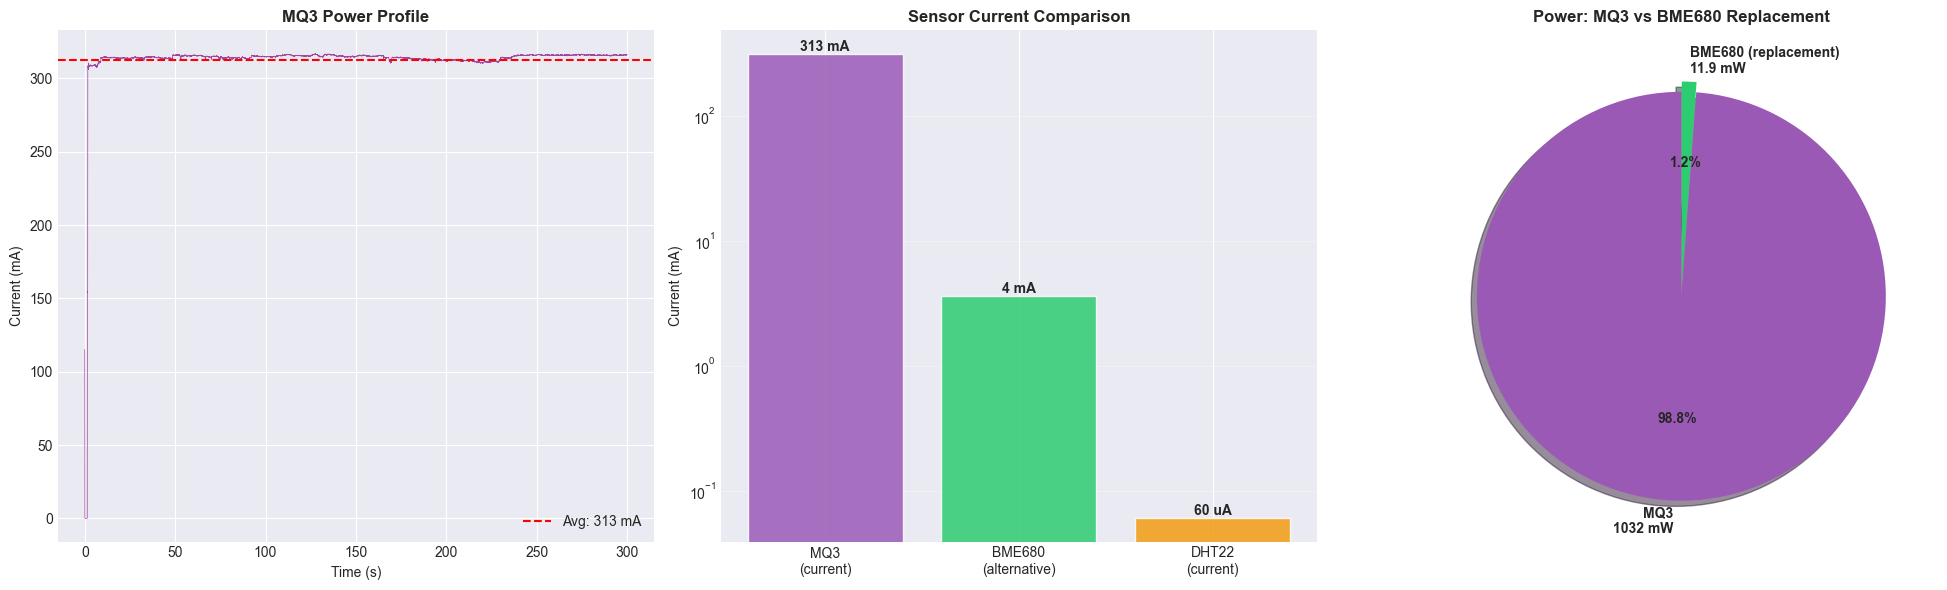

MQ3 average current:  312.9 mA (1032 mW)
BME680 active current: 3.6 mA (11.9 mW)
Reduction: 87x less current

BME680 also replaces DHT22, reducing component count.


In [77]:
if mq3_df is not None:
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

    # MQ3 power profile
    ax1.plot(mq3_df['time_sec'], mq3_df['current_ma'], linewidth=0.5, color='purple', alpha=0.7)
    avg_mq3 = mq3_df['current_ma'].mean()
    ax1.axhline(avg_mq3, color='red', linestyle='--', linewidth=1.5, label=f'Avg: {avg_mq3:.0f} mA')
    ax1.set_xlabel('Time (s)'); ax1.set_ylabel('Current (mA)')
    ax1.set_title('MQ3 Power Profile', fontweight='bold'); ax1.legend()

    # Comparison bar
    sensors = ['MQ3\n(current)', 'BME680\n(alternative)', 'DHT22\n(current)']
    currents = [avg_mq3, BME680_ACTIVE_UA/1000, DHT22_STANDBY_UA/1000]
    colors_s = ['#9b59b6', '#2ecc71', '#f39c12']
    bars = ax2.bar(sensors, currents, color=colors_s, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, currents):
        label = f'{v:.0f} mA' if v > 1 else f'{v*1000:.0f} uA'
        ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height(), label, ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax2.set_ylabel('Current (mA)'); ax2.set_title('Sensor Current Comparison', fontweight='bold')
    ax2.set_yscale('log'); ax2.grid(axis='y', alpha=0.3)

    # Energy per hour comparison (sensor only)
    mq3_wh = avg_mq3 * SUPPLY_VOLTAGE / 1000  # Watts
    bme_wh = (BME680_ACTIVE_UA/1000) * SUPPLY_VOLTAGE / 1000
    dht_wh = (DHT22_STANDBY_UA/1000) * SUPPLY_VOLTAGE / 1000
    ax3.pie([mq3_wh, bme_wh + dht_wh],
            labels=[f'MQ3\n{mq3_wh*1000:.0f} mW', f'BME680 (replacement)\n{bme_wh*1000:.1f} mW'],
            colors=['#9b59b6', '#2ecc71'], autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 10, 'fontweight': 'bold'}, explode=[0.05, 0], shadow=True)
    ax3.set_title('Power: MQ3 vs BME680 Replacement', fontweight='bold')

    plt.tight_layout(); plt.show()

    print(f"MQ3 average current:  {avg_mq3:.1f} mA ({avg_mq3*SUPPLY_VOLTAGE:.0f} mW)")
    print(f"BME680 active current: {BME680_ACTIVE_UA/1000:.1f} mA ({BME680_ACTIVE_UA/1000*SUPPLY_VOLTAGE:.1f} mW)")
    print(f"Reduction: {avg_mq3/(BME680_ACTIVE_UA/1000):.0f}x less current")
    print(f"\nBME680 also replaces DHT22, reducing component count.")

## 12. Proposed Improvements — Quantified Impact

### Overview of Proposed Changes

| # | Improvement | What Changes | Estimated Saving |
|---|------------|-------------|-----------------|
| 1 | **MOSFET power gates for SGP30 + DHT22** | P-channel MOSFET on sensor V+ lines, GPIO-controlled. Cuts sensor power during deep sleep. | **-48.06 mA/node idle** |
| 2 | **SGP30 firmware sleep command** | Send `sgp30_sleep` via I2C before ESP32 deep sleep. Software-only fix, no hardware changes. | Same as #1 (alternative approach) |
| 3 | **Custom PCB (replace DevKit)** | Bare ESP32-WROOM module + efficient LDO (MCP1700, 1.6 µA quiescent). Eliminates AMS1117 LDO, USB-UART bridge, power LED. | **-12 mA/node idle** |
| 4 | **Replace MQ3 + DHT22 with BME680** | Single I2C sensor for temp, humidity, gas resistance. 3.6 mA active, 0.15 µA sleep. | **-310 mA external, -0.06 mA/node** |
| 5 | **Replace SGP30 with SGP41** | Newer Sensirion VOC sensor with better power management. 34 mA active, 2 µA sleep. | **-14 mA/node active** |

**Total hardware cost for improvements 1+3: ~€5–10 per node** (MOSFET + resistors + custom PCB + efficient LDO)

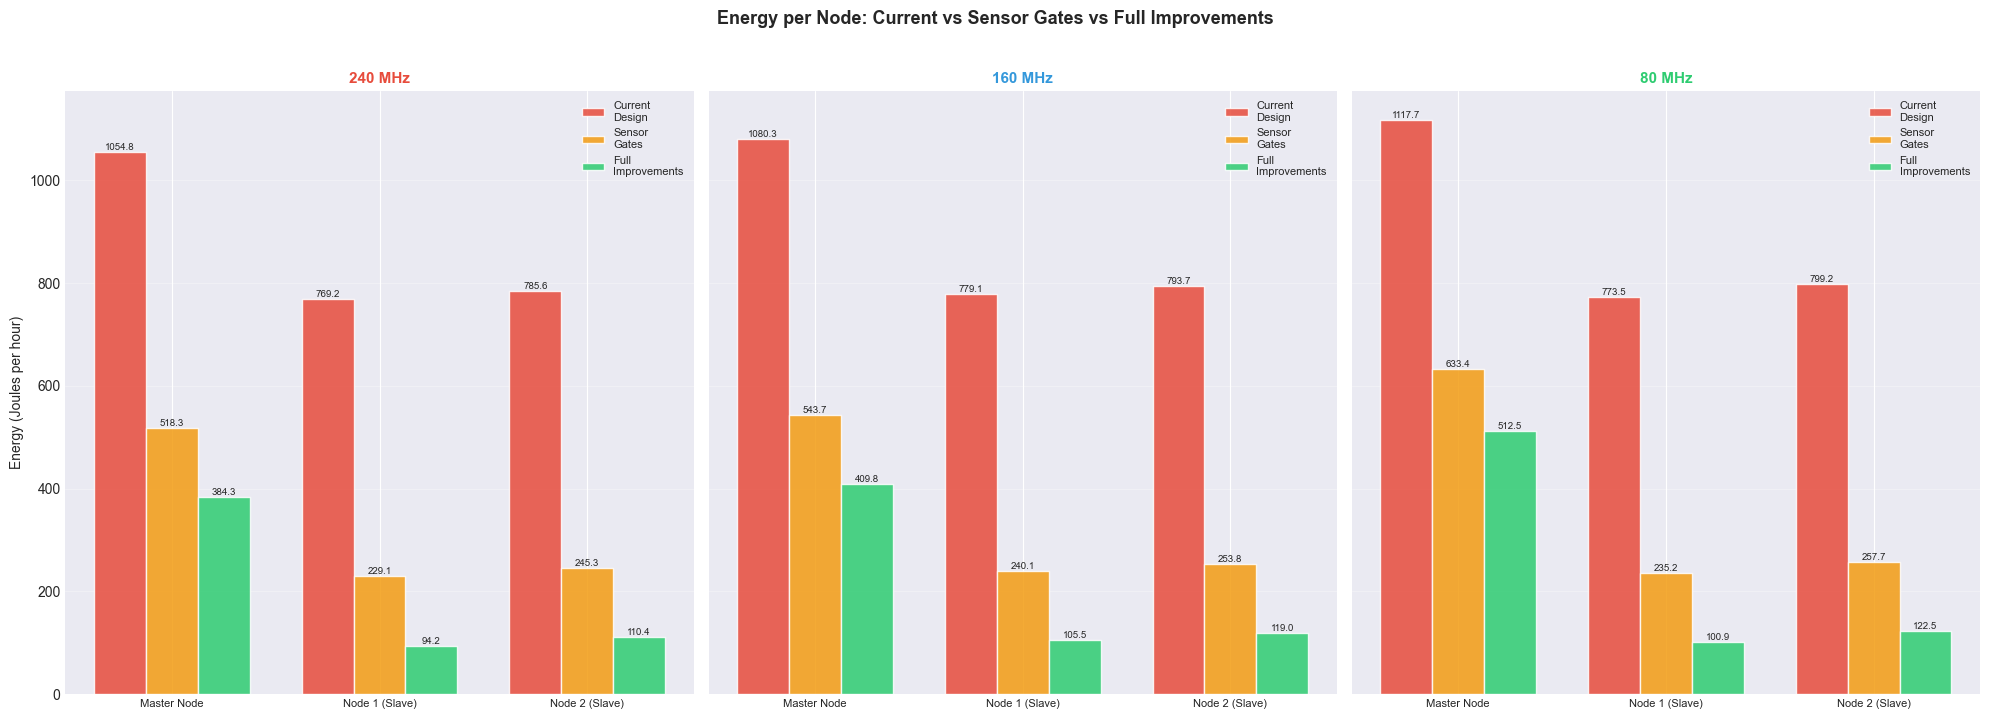

In [78]:
# ── Three scenarios: current / sensor-gated / full improvements ───────────────
scenarios_data = []

for freq in FREQS:
    for node in NODES:
        df = processed[freq][node]
        if df is None: continue
        dur = df['time_sec'].max() - df['time_sec'].min()
        avg_actual = df['current_ma'].mean()
        idle_baseline = df['current_ma'].quantile(0.05)  # measured idle

        # Scenario 1: Current design (as measured)
        energy_actual = (avg_actual / 1000) * SUPPLY_VOLTAGE * dur

        # Scenario 2: Sensor gates only (remove SGP30 + DHT22 from idle)
        sensor_waste_ma = (SGP30_ACTIVE_UA + DHT22_STANDBY_UA) / 1000  # 48.06 mA
        # Estimate idle fraction from data
        threshold = df['current_ma'].mean() + 1.0 * df['current_ma'].std()
        idle_frac = (df['current_ma'] <= threshold).sum() / len(df)
        avg_gated = avg_actual - (sensor_waste_ma * idle_frac)
        energy_gated = (avg_gated / 1000) * SUPPLY_VOLTAGE * dur

        # Scenario 3: Full improvements (sensor gates + custom PCB)
        devkit_waste_ma = DEVKIT_OVERHEAD_UA / 1000  # ~12 mA
        # Custom PCB replaces DevKit overhead with efficient LDO
        avg_full = avg_gated - (devkit_waste_ma * idle_frac) + (EFFICIENT_LDO_UA / 1000 * idle_frac)
        energy_full = (avg_full / 1000) * SUPPLY_VOLTAGE * dur

        scenarios_data.append({
            'freq': freq, 'node': NODE_LABELS[node],
            'idle_pct': idle_frac * 100,
            'measured_idle_ma': idle_baseline,
            'avg_actual_ma': avg_actual, 'avg_gated_ma': avg_gated, 'avg_full_ma': avg_full,
            'energy_actual_j': energy_actual, 'energy_gated_j': energy_gated, 'energy_full_j': energy_full,
        })

scen_df = pd.DataFrame(scenarios_data)

# ── Bar charts per frequency ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(FREQS), figsize=(20, 7), sharey=True)
scenario_labels = ['Current\nDesign', 'Sensor\nGates', 'Full\nImprovements']
scenario_colors = ['#e74c3c', '#f39c12', '#2ecc71']

for ax, freq in zip(axes, FREQS):
    subset = scen_df[scen_df['freq'] == freq]
    x = np.arange(len(NODES)); w = 0.25
    for i, (col, label, color) in enumerate(zip(
        ['energy_actual_j', 'energy_gated_j', 'energy_full_j'], scenario_labels, scenario_colors)):
        vals = subset[col].values
        bars = ax.bar(x + i*w, vals, w, label=label, color=color, alpha=0.85, edgecolor='white')
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(), f'{v:.1f}', ha='center', va='bottom', fontsize=7)
    ax.set_xticks(x + w); ax.set_xticklabels([NODE_LABELS[n] for n in NODES], fontsize=8)
    ax.set_title(FREQ_LABELS[freq], fontsize=11, fontweight='bold', color=FREQ_COLORS[freq])
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel('Energy (Joules per hour)')
fig.suptitle('Energy per Node: Current vs Sensor Gates vs Full Improvements', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

### System-Level Improvement Impact

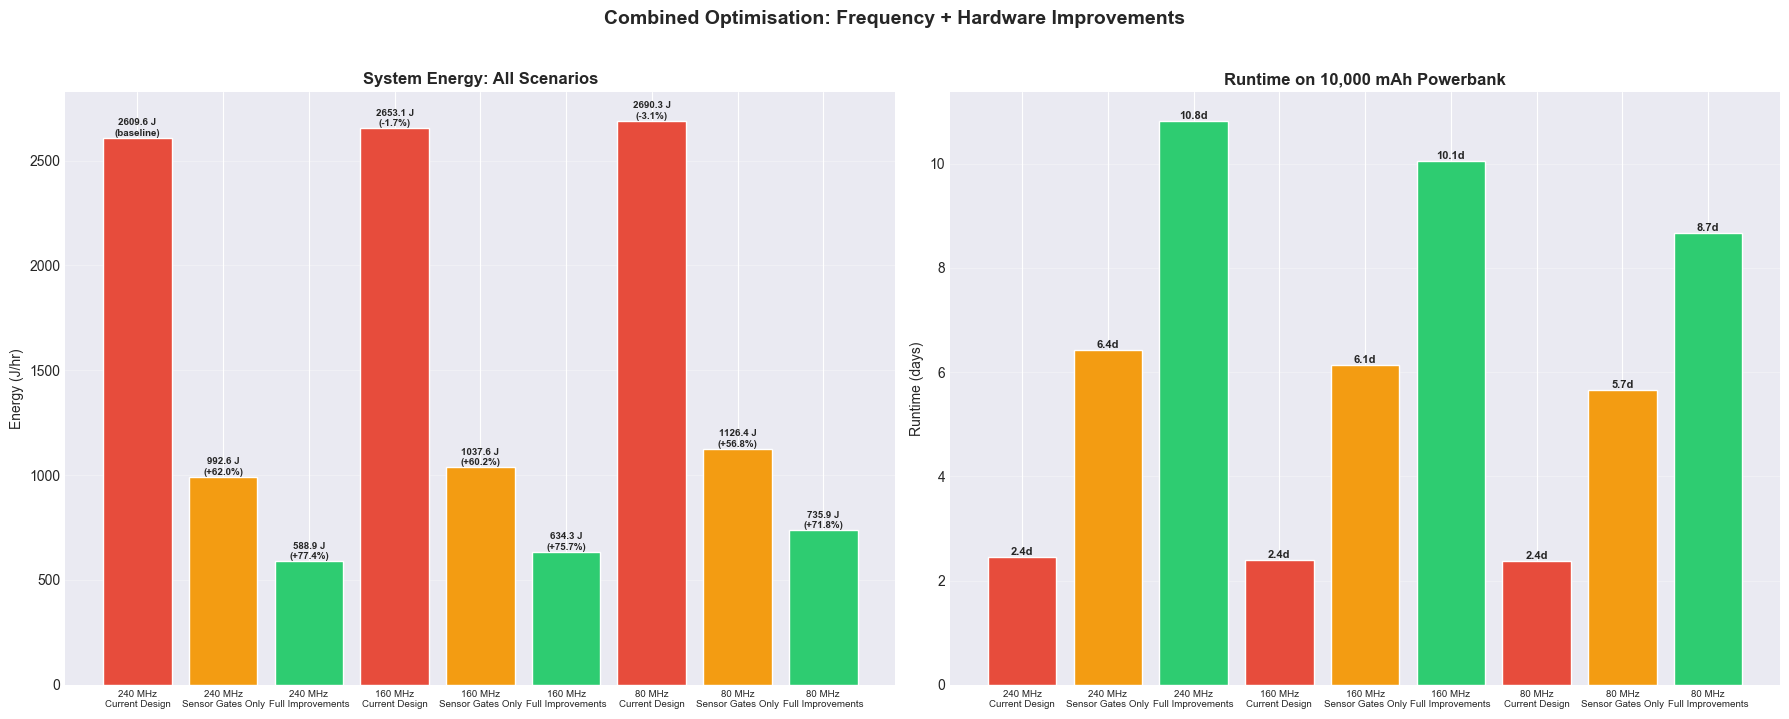


OPTIMISATION SUMMARY
  Worst: 80 MHz Current Design -> 2690.3 J/hr | 2.4 days on 10Ah
  Best:  240 MHz Full Improvements -> 588.9 J/hr | 11 days on 10Ah
  Total improvement: 78.1%


In [79]:
# ── System totals per scenario per frequency ──────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

sys_scenarios = []
for freq in FREQS:
    subset = scen_df[scen_df['freq'] == freq]
    if len(subset) < 3: continue
    for variant, col_e, col_c in [
        ('Current Design', 'energy_actual_j', 'avg_actual_ma'),
        ('Sensor Gates Only', 'energy_gated_j', 'avg_gated_ma'),
        ('Full Improvements', 'energy_full_j', 'avg_full_ma'),
    ]:
        sys_scenarios.append({
            'label': f'{FREQ_LABELS[freq]}\n{variant}',
            'freq': freq, 'variant': variant,
            'total_energy_j': subset[col_e].sum(),
            'total_current_ma': subset[col_c].sum(),
        })

ss_df = pd.DataFrame(sys_scenarios)
baseline_j = ss_df[(ss_df['freq']==240)&(ss_df['variant']=='Current Design')]['total_energy_j'].values[0]

# Color mapping
vc = {'Current Design': 0.85, 'Sensor Gates Only': 0.55, 'Full Improvements': 0.25}
colors = [FREQ_COLORS[r['freq']] + ['D9','8C','40'][['Current Design','Sensor Gates Only','Full Improvements'].index(r['variant'])]
          if False else ['#e74c3c','#f39c12','#2ecc71'][['Current Design','Sensor Gates Only','Full Improvements'].index(r['variant'])]
          for _, r in ss_df.iterrows()]

x = np.arange(len(ss_df))
bars = ax1.bar(x, ss_df['total_energy_j'], color=colors, edgecolor='white', width=0.8)
for bar, v in zip(bars, ss_df['total_energy_j']):
    s = (1 - v/baseline_j)*100
    lb = f'{v:.1f} J\n({s:+.1f}%)' if s != 0 else f'{v:.1f} J\n(baseline)'
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height(), lb, ha='center', va='bottom', fontsize=7, fontweight='bold')
ax1.set_xticks(x); ax1.set_xticklabels(ss_df['label'], fontsize=7, rotation=0)
ax1.set_ylabel('Energy (J/hr)'); ax1.set_title('System Energy: All Scenarios', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Runtime on 10k mAh
usable = 10000 * (5.0/3.3) * POWERBANK_EFF
ss_df['days'] = usable / ss_df['total_current_ma'] / 24
bars = ax2.bar(x, ss_df['days'], color=colors, edgecolor='white', width=0.8)
for bar, d in zip(bars, ss_df['days']):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height(),
             f'{d:.1f}d' if d < 100 else f'{d:.0f}d', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax2.set_xticks(x); ax2.set_xticklabels(ss_df['label'], fontsize=7, rotation=0)
ax2.set_ylabel('Runtime (days)'); ax2.set_title('Runtime on 10,000 mAh Powerbank', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

fig.suptitle('Combined Optimisation: Frequency + Hardware Improvements', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# Print summary
best = ss_df.loc[ss_df['total_energy_j'].idxmin()]
worst = ss_df.loc[ss_df['total_energy_j'].idxmax()]
print(f"\n{'='*75}")
print("OPTIMISATION SUMMARY")
print(f"{'='*75}")
print(f"  Worst: {worst['label'].replace(chr(10), ' ')} -> {worst['total_energy_j']:.1f} J/hr | {worst['days']:.1f} days on 10Ah")
print(f"  Best:  {best['label'].replace(chr(10), ' ')} -> {best['total_energy_j']:.1f} J/hr | {best['days']:.0f} days on 10Ah")
print(f"  Total improvement: {(1-best['total_energy_j']/worst['total_energy_j'])*100:.1f}%")

## 13. Powerbank Runtime Projections

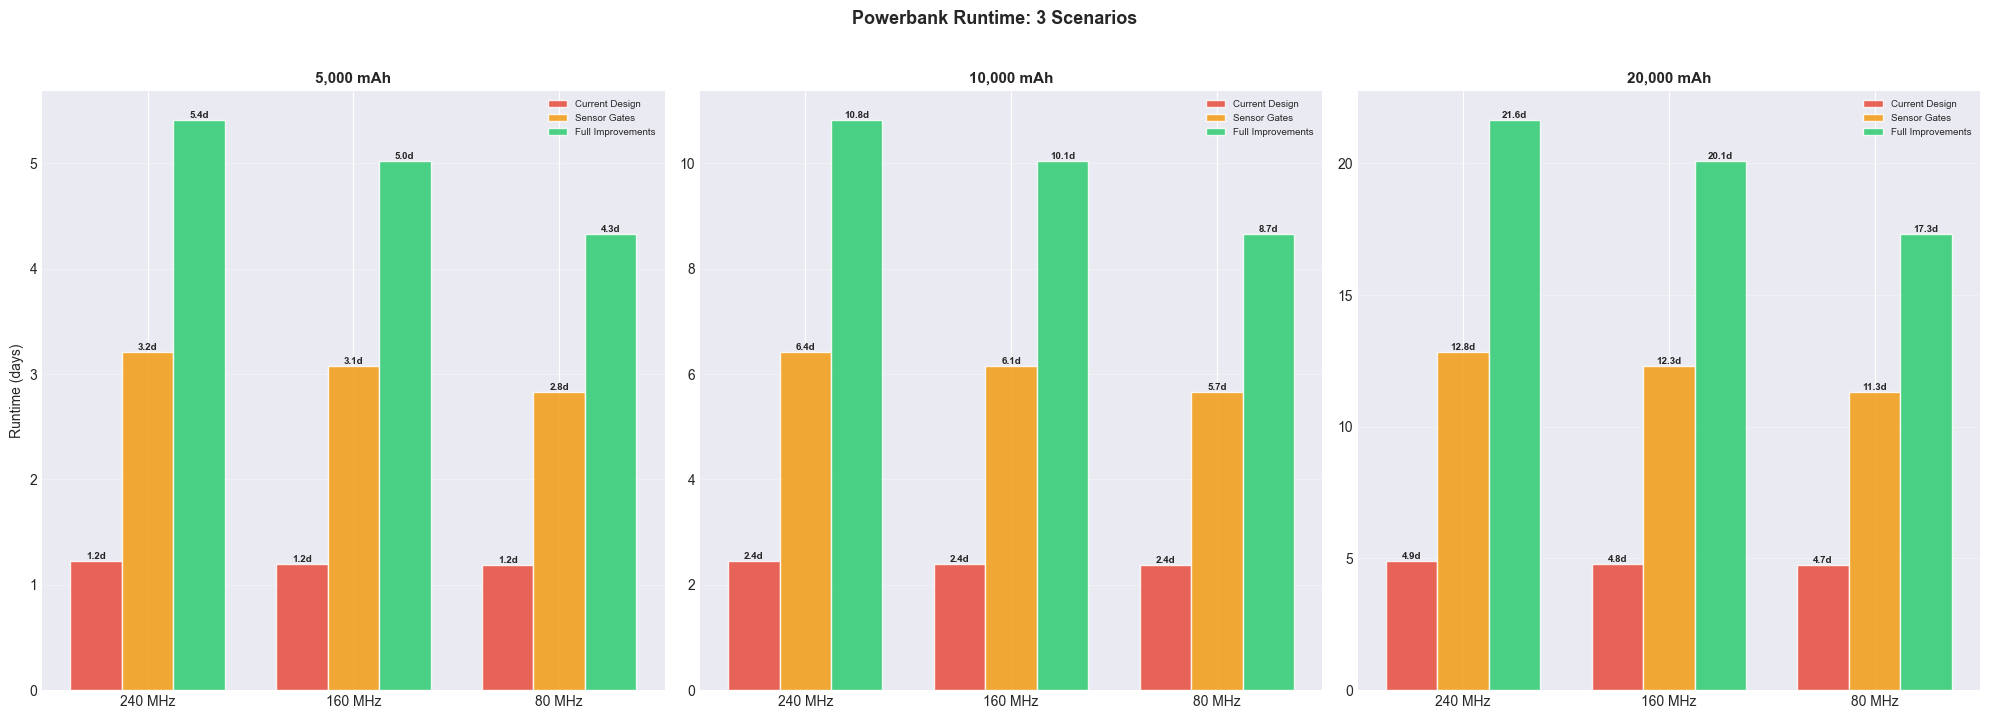

In [80]:
runtime_data = []
for freq in FREQS:
    subset = scen_df[scen_df['freq']==freq]
    if len(subset) < 3: continue
    for cap in POWERBANK_MAH:
        usable = cap * (5.0/3.3) * POWERBANK_EFF
        for variant, col in [('Current Design', 'avg_actual_ma'), ('Sensor Gates', 'avg_gated_ma'), ('Full Improvements', 'avg_full_ma')]:
            total_ma = subset[col].sum()
            hrs = usable / total_ma
            runtime_data.append({'freq': freq, 'capacity_mah': cap, 'variant': variant,
                                 'total_ma': total_ma, 'hours': hrs, 'days': hrs/24})

rt_df = pd.DataFrame(runtime_data)

fig, axes = plt.subplots(1, len(POWERBANK_MAH), figsize=(20, 7), sharey=False)
variant_colors = {'Current Design': '#e74c3c', 'Sensor Gates': '#f39c12', 'Full Improvements': '#2ecc71'}

for ax, cap in zip(axes, POWERBANK_MAH):
    subset = rt_df[rt_df['capacity_mah']==cap]
    x = np.arange(len(FREQS)); w = 0.25
    for i, variant in enumerate(['Current Design', 'Sensor Gates', 'Full Improvements']):
        vs = subset[subset['variant']==variant]
        bars = ax.bar(x + i*w, vs['days'], w, label=variant, color=variant_colors[variant], alpha=0.85, edgecolor='white')
        for bar, d in zip(bars, vs['days']):
            lb = f'{d:.1f}d' if d < 100 else f'{d:.0f}d'
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(), lb, ha='center', va='bottom', fontsize=7, fontweight='bold')
    ax.set_xticks(x+w); ax.set_xticklabels([FREQ_LABELS[f] for f in FREQS])
    ax.set_title(f'{cap:,} mAh', fontsize=11, fontweight='bold')
    ax.legend(fontsize=7); ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel('Runtime (days)')
fig.suptitle('Powerbank Runtime: 3 Scenarios', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

## 14. Summary: Strengths & Weaknesses

### What Works Well
- **ESP-NOW mesh** is extremely energy-efficient for inter-node communication
- **15-minute deep sleep cycles** are well-suited for environmental monitoring
- **The ESP32 chip itself** achieves excellent deep-sleep current (~10 µA)
- **Multi-node architecture** provides spatial coverage with minimal active time per node
- **PPK2 profiling** has identified clear, actionable optimisation targets

### What Needs Improvement
1. **SGP30 is the #1 power hog** — 48 mA continuous during ESP32 deep sleep (80% of node idle power). Either gate with MOSFET or send `sgp30_sleep` I2C command before ESP32 sleep.
2. **DevKit boards waste ~12 mA** — the AMS1117 LDO alone draws 5 mA quiescent. A custom PCB with MCP1700 (1.6 µA) eliminates this.
3. **MQ3 draws 310 mA** — its resistive heater makes battery operation impractical. Consider the MiCS-5524 MEMS sensor (25-35 mA with enable pin) or the SGP30 raw ethanol signal already available in the current system.
4. **CPU frequency has minimal impact** — because nodes spend >90% of time idle, the active-phase savings from 80 MHz vs 240 MHz are dwarfed by the idle overhead.
5. **DHT22 is fine** — at 60 µA standby it contributes < 0.1% of idle power. Not a priority for optimisation.

In [81]:
# ── Final summary table ────────────────────────────────────────────────────────
print(f"{'='*100}")
print("DETAILED STATISTICS (per node, 1 hour)")
print(f"{'='*100}")
print(f"{'Freq':<8} {'Node':<18} {'Measured':>10} {'Gated':>10} {'Full Improv':>12} {'Saving':>8}")
print(f"{'':<8} {'':<18} {'(mA)':>10} {'(mA)':>10} {'(mA)':>12} {'(%)':>8}")
print(f"{'-'*8} {'-'*18} {'-'*10} {'-'*10} {'-'*12} {'-'*8}")

for freq in FREQS:
    for node in NODES:
        r = scen_df[(scen_df['freq']==freq) & (scen_df['node']==NODE_LABELS[node])]
        if len(r):
            r = r.iloc[0]
            pct = (1 - r['avg_full_ma']/r['avg_actual_ma'])*100
            print(f"{FREQ_LABELS[freq]:<8} {NODE_LABELS[node]:<18} "
                  f"{r['avg_actual_ma']:>10.2f} {r['avg_gated_ma']:>10.2f} {r['avg_full_ma']:>12.2f} {pct:>7.1f}%")
    print()

print(f"{'='*100}")
print("SYSTEM TOTALS (3 nodes)")
print(f"{'='*100}")
for freq in FREQS:
    s = scen_df[scen_df['freq']==freq]
    if len(s)==3:
        ca = s['avg_actual_ma'].sum(); cg = s['avg_gated_ma'].sum(); cf = s['avg_full_ma'].sum()
        ea = s['energy_actual_j'].sum(); eg = s['energy_gated_j'].sum(); ef = s['energy_full_j'].sum()
        print(f"  {FREQ_LABELS[freq]:<8}  Measured: {ca:.1f} mA / {ea:.1f} J  |  "
              f"Gated: {cg:.1f} mA / {eg:.1f} J  |  "
              f"Full: {cf:.1f} mA / {ef:.1f} J  ({(1-ef/ea)*100:.1f}% saved)")

DETAILED STATISTICS (per node, 1 hour)
Freq     Node                 Measured      Gated  Full Improv   Saving
                                  (mA)       (mA)         (mA)      (%)
-------- ------------------ ---------- ---------- ------------ --------
240 MHz  Master Node             88.79      43.63        32.35    63.6%
240 MHz  Node 1 (Slave)          64.75      19.28         7.93    87.8%
240 MHz  Node 2 (Slave)          66.13      20.65         9.29    85.9%

160 MHz  Master Node             90.94      45.77        34.49    62.1%
160 MHz  Node 1 (Slave)          65.58      20.21         8.88    86.5%
160 MHz  Node 2 (Slave)          66.81      21.36        10.02    85.0%

80 MHz   Master Node             94.08      53.32        43.14    54.1%
80 MHz   Node 1 (Slave)          65.11      19.80         8.49    87.0%
80 MHz   Node 2 (Slave)          67.27      21.69        10.32    84.7%

SYSTEM TOTALS (3 nodes)
  240 MHz   Measured: 219.7 mA / 2609.6 J  |  Gated: 83.6 mA / 992.6 J

## 15. Thesis Notes — Design Improvements & Recommendations

> **These notes are reference material for the thesis write-up.** They expand on the quantified findings above.

---

### 15.1 DevKit Board Overhead (~12 mA)

After power-gating the SGP30 (48 mA) and DHT22 (60 µA), the **remaining ~12 mA idle current** comes from components on the ESP32 DevKit board that cannot be disabled in software:

| Component | Est. Current | Role |
|---|---|---|
| **AMS1117 LDO regulator** | ~5 mA quiescent | Converts 5 V USB to 3.3 V. Even at zero load this cheap linear regulator wastes ~5 mA. |
| **CP2102 USB-UART bridge** | ~5 mA | USB-to-serial chip for flashing/debug. Always powered, even during deep sleep. |
| **Power LED** | ~2 mA | Board indicator LED, always on. |

The ESP32 chip itself achieves ~10 µA in deep sleep, but these three board-level components dominate the remaining power budget. **This is why CPU frequency optimisation has minimal impact** — the ESP32 is asleep 99.7% of the time, and during sleep the board overhead + SGP30 dwarf the CPU contribution.

---

### 15.2 Sensor Power Gating (P-Channel MOSFET)

**What it is:** A hardware modification where a P-channel MOSFET is placed between the 3.3 V rail and each sensor’s VCC pin. An ESP32 GPIO controls the MOSFET gate.

**How it works:**
- Before deep sleep: GPIO HIGH → MOSFET OFF → sensor loses power → 0 mA
- On wake-up: GPIO LOW → MOSFET ON → sensor powers up → take reading → sleep

**Suitable MOSFETs:** IRLML6402 or AO3401 (P-channel, logic-level gate threshold).

**Impact:** Cuts idle current from ~60 mA to ~12 mA per node (**-80%**). The SGP30 has a ~15 s warm-up after power-on, but on 15-minute cycles this adds < 2% to active time.

**This is the single highest-impact, lowest-effort improvement available.** It requires only a MOSFET, a pull-up resistor, and one GPIO per sensor group.

---

### 15.3 Custom PCB with Efficient LDO

**What it is:** Replacing the off-the-shelf ESP32 DevKit with a custom PCB carrying just the ESP32-WROOM-32 module and minimal support circuitry.

**Key changes:**
| DevKit Component | Replacement | Current Saving |
|---|---|---|
| AMS1117 LDO (~5 mA quiescent) | MCP1700 (~1.6 µA) or HT7333 (~3 µA) | ~5 mA saved |
| CP2102 USB-UART (always on) | External programming header (6-pin) | ~5 mA saved |
| Power LED (~2 mA) | Removed or jumpered | ~2 mA saved |

**Impact:** Deep sleep idle drops from ~12 mA (DevKit) to **~10 µA** (ESP32 chip + efficient LDO). Combined with sensor gating, total system idle becomes negligible.

**Practicality:** This is a larger undertaking (PCB design, ordering, assembly) and is best positioned as a **future work** recommendation in the thesis, while MOSFET gating is the practical near-term solution.

---

### 15.4 MQ3 Ethanol Sensor — Alternatives

The MQ3 draws ~310 mA continuously due to its resistive heater element, making it impractical for battery-powered operation. Below are formal ethanol-capable alternatives:

| Sensor | Type | Ethanol Range | Active Current | Power Gatable | Interface | Open-Source Library |
|---|---|---|---|---|---|---|
| **SGP30** (already in system) | MOX (Sensirion) | Raw ethanol signal, up to 1000 ppm tested | 48 mA | Yes (with warm-up) | I2C | Yes — Adafruit, RobTillaart |
| **MiCS-5524** | MEMS (SGX Sensortech) | 10–500 ppm ethanol | 25–35 mA (heater) | Yes (enable pin) | Analog + ADC | Yes — Adafruit breakout |
| **SGP40 / SGP41** | MOX (Sensirion) | VOC Index (inc. ethanol) | 2.6–3.2 mA | Yes | I2C | Yes — Sensirion, Adafruit |
| **TGS2620** | MOX (Figaro) | 50–5000 ppm ethanol | 46 mA (heater) | Partial | Analog + ADC | Community libs |

**Key observations:**
1. **SGP30 raw ethanol signal** — The SGP30 already in the system exposes raw ethanol and H₂ signals via I2C (). While not factory-calibrated for absolute ppm, it provides a **relative ethanol indicator** suitable for detecting mold-related fermentation changes. This requires no hardware change, only a firmware addition.
2. **MiCS-5524** — Best dedicated ethanol alternative. MEMS-based, ~30 mA active, has an enable pin for power management, and Adafruit provides an open-source breakout + library. ~10x less power than MQ3.
3. **SGP40/SGP41** — Lowest power option (3.2 mA), Sensirion’s successor to SGP30 with open-source I2C drivers. Outputs a VOC index that includes ethanol response, but not a direct ppm reading.

**Recommendation for thesis:** Note that the SGP30 raw ethanol capability is already available. For future iterations, the MiCS-5524 offers a formal ethanol measurement at ~10x lower power than the MQ3, with an enable pin for duty-cycling.
